In [31]:
import numpy as np
import math
import json
from scipy.special import erfc
from scipy.stats import poisson
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit

In [33]:
# ============================================================
# GEOMETRIC PARAMETERS (cm)
# ============================================================
Lx = 0.2
Ly = 0.2
Lz = 0.2

dx = 0.001
FCCD_cm = 0.1

In [34]:
# ============================================================
# DIFFUSION
# ============================================================
D = 28.9
dt = 1.0
t_max = 10000
Nt = int(t_max / dt)
sigma = math.sqrt(6 * D * dt) * 1e-4

In [37]:
# ============================================================
# LITHIUM
# ============================================================
r_Li = 0.002   # cm
cell_size = r_Li


In [36]:
# ============================================================
# ANNEALING
# ============================================================
t_ann = 18 * 60
T_ann = 623

R = 1.98
H = 11800
D0 = 2.5e-3

Ns = 10 ** (21.27 - 2610 / T_ann)
D_Li = D0 * math.exp(-H / (R * T_ann))

Nd_saturation = 1e14
alpha = 1.6e-11

In [38]:

# ============================================================
# SATURATION DEPTH
# ============================================================
depth_list = np.arange(0, 0.11 + dx, dx)
Nd_vals = Ns * erfc(depth_list / (2 * np.sqrt(D_Li * t_ann)))

idx = np.where(Nd_vals - Nd_saturation <= 0)[0][0]
saturation_depth = depth_list[idx]

print("Saturation depth =", saturation_depth * 10, "mm")

Saturation depth = 0.66 mm


In [39]:
# ============================================================
# LITHIUM PARTICLE
# ============================================================
class LiParticle:
    __slots__ = ("x", "y", "z", "r")

    def __init__(self, x, y, z, r):
        self.x = x
        self.y = y
        self.z = z
        self.r = r

In [46]:
# ============================================================
# TRUNCATED POISSON
# ============================================================
def truncated_poisson(lam, Nmax):
    if Nmax <= 0:
        return 0

    for _ in range(100):
        n = np.random.poisson(lam)
        if n <= Nmax:
            return n

    return Nmax

In [42]:
# ============================================================
# GRID INDEXING
# ============================================================
def get_index(x, y, z, nx, ny, nz):
    ix = min(max(int(x / cell_size), 0), nx - 1)
    iy = min(max(int(y / cell_size), 0), ny - 1)
    iz = min(max(int(z / cell_size), 0), nz - 1)
    return ix, iy, iz


In [43]:
# ============================================================
# OVERLAP CHECK
# ============================================================
def is_overlapping(x, y, z, r, cells, nx, ny, nz):
    ix, iy, iz = get_index(x, y, z, nx, ny, nz)

    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for dz in (-1, 0, 1):
                jx, jy, jz = ix + dx, iy + dy, iz + dz

                if 0 <= jx < nx and 0 <= jy < ny and 0 <= jz < nz:
                    for p in cells[jx][jy][jz]:
                        if (x - p.x)**2 + (y - p.y)**2 + (z - p.z)**2 < (r + p.r)**2:
                            return True
    return False


In [44]:
# ============================================================
# LITHIUM GENERATION
# ============================================================
def generate_lithium():
    nx = int(Lx / cell_size)
    ny = int(Ly / cell_size)
    nz = int(Lz / cell_size)

    cells = [[[[] for _ in range(nz)] for _ in range(ny)] for _ in range(nx)]

    x_slices = np.arange(0, Lx + dx, dx)
    total = 0

    for xi in x_slices:
        if xi >= saturation_depth:
            continue

        Nd_val = Ns * erfc(xi / (2 * np.sqrt(D_Li * t_ann)))
        density = alpha * max(Nd_val - Nd_saturation, 0.0)

        lam = density * dx * Ly * Lz

        V_particle = (4/3) * math.pi * r_Li**3
        V_slice = dx * Ly * Lz
        N_max = int(V_slice / V_particle)

        N_i = truncated_poisson(lam, N_max)

        accepted = 0
        trials = N_i * 100

        for _ in range(trials):
            if accepted >= N_i:
                break

            x = xi + np.random.rand() * dx
            y = np.random.rand() * Ly
            z = np.random.rand() * Lz

            if not is_overlapping(x, y, z, r_Li, cells, nx, ny, nz):
                ix, iy, iz = get_index(x, y, z, nx, ny, nz)
                cells[ix][iy][iz].append(LiParticle(x, y, z, r_Li))
                accepted += 1
                total += 1

    print("Total Li particles =", total)
    return cells


In [47]:
# ============================================================
# GENERATE LITHIUM
# ============================================================
cells = generate_lithium()

Total Li particles = 1269


In [48]:
# ============================================================
# CHARGE TRANSPORT + TRAPPING
# ============================================================
def charge_transport_3D(x_charges, N, cells,
                        x_saturation, dx,
                        Lx, Ly, Lz,
                        Nt, sigma, FCCD_cm, r):

    if np.isscalar(x_charges):
        x_charges = np.full(N, x_charges)

    nx = len(cells)
    ny = len(cells[0])
    nz = len(cells[0][0])

    collected = 0
    trapped = 0

    for n in range(N):
        x = x_charges[n]
        y = np.random.rand() * Ly
        z = np.random.rand() * Lz

        is_trapped = False

        for _ in range(Nt):
            x += sigma * np.random.randn()
            y += sigma * np.random.randn()
            z += sigma * np.random.randn()

            x = np.clip(x, 0, Lx)
            y = np.clip(y, 0, Ly)
            z = np.clip(z, 0, Lz)

            if x >= FCCD_cm:
                collected += 1
                break

            if x <= dx:
                is_trapped = True
                break

            if x <= x_saturation:
                ix, iy, iz = get_index(x, y, z, nx, ny, nz)

                for dx_ in (-1, 0, 1):
                    for dy_ in (-1, 0, 1):
                        for dz_ in (-1, 0, 1):
                            jx, jy, jz = ix + dx_, iy + dy_, iz + dz_

                            if 0 <= jx < nx and 0 <= jy < ny and 0 <= jz < nz:
                                for p in cells[jx][jy][jz]:
                                    if (x - p.x)**2 + (y - p.y)**2 + (z - p.z)**2 < r**2:
                                        is_trapped = True
                                        break

                            if is_trapped:
                                break
                        if is_trapped:
                            break

            if is_trapped:
                trapped += 1
                break

    return collected, trapped

In [50]:
# ============================================================
# CCE SIMULATION
# ============================================================
dx = 0.01
x_pos = np.arange(0, 0.11 + dx, dx)
N_charges = 25
N_repeat = 2

CCE_matrix = np.zeros((len(x_pos), N_repeat))

for i, x0 in enumerate(tqdm(x_pos)):
    for j in range(N_repeat):
        collected, _ = charge_transport_3D(
            x0, N_charges, cells,
            saturation_depth, dx,
            Lx, Ly, Lz,
            Nt, sigma, FCCD_cm, r_Li
        )
        CCE_matrix[i, j] = collected / N_charges


100%|██████████| 12/12 [00:05<00:00,  2.04it/s]


In [51]:
# ============================================================
# STATISTICS
# ============================================================
CCE_mean = CCE_matrix.mean(axis=1)
CCE_std = CCE_matrix.std(axis=1)


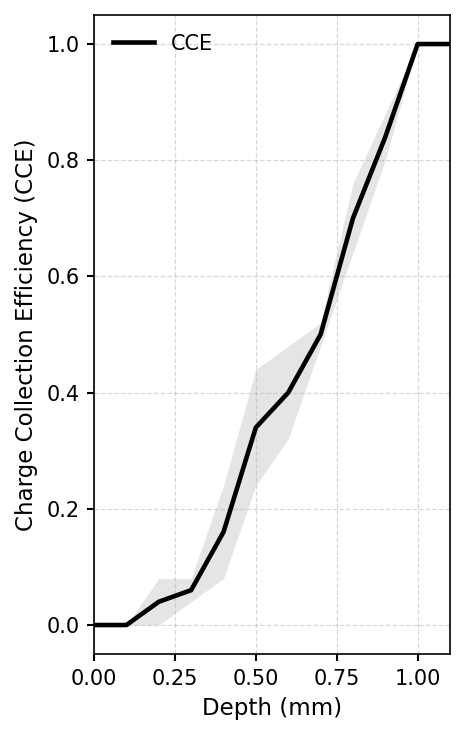

In [61]:
fig, ax = plt.subplots(figsize=(3.2, 5), dpi=150)

# Main curve
ax.plot(
    x_pos * 10,
    CCE_mean,
    lw=2.2,
    color="black",
    label="CCE"
)

# Uncertainty band (more transparent and cleaner)
ax.fill_between(
    x_pos * 10,
    CCE_mean - CCE_std,
    CCE_mean + CCE_std,
    alpha=0.2,
    color="gray",
    linewidth=0
)

# Labels (slightly larger + clearer units)
ax.set_xlabel("Depth (mm)", fontsize=11)
ax.set_ylabel("Charge Collection Efficiency (CCE)", fontsize=11)

# Grid (major only, subtle)
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.5)

# Improve axes limits (removes useless whitespace)
ax.set_xlim(x_pos.min() * 10, x_pos.max() * 10)


# Tick styling
ax.tick_params(axis="both", which="major", labelsize=10, width=1)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# SAVE RESULTS
# ============================================================
filename = f"JSON/CCE_{r_Li*10000}um.json"

results = {
    "x_pos": x_pos.tolist(),
    "CCE_mean": CCE_mean.tolist(),
    "CCE_std": CCE_std.tolist()
}

if os.path.exists(filename):
    ans = input(f"{filename} exists. Overwrite? (y/n): ")
    if ans.lower() != "y":
        print("Cancelled")
        exit()

os.makedirs("JSON", exist_ok=True)
with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print("File saved:", filename)

File saved: JSON/CCE_20.0um.json
